# Problem 5: Iris Dataset

Use

Python

from sklearn.datasets import load_iris

Questions

Decision Tree বানাও।

Visualization করো।

Max Depth পরিবর্তন করলে কী হয়?

Feature Importance বের করো।

কোন Feature Root Node হয়েছে?

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


from sklearn.datasets import load_iris

from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,precision_score,recall_score
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


In [11]:
df=load_iris(as_frame=True).frame
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [12]:
x=df.drop('target',axis=1)
y=df['target']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)

In [14]:
grid={
    'criterion':['gini','entropy'],
    'max_depth':[1,2,3,4,5,6,7,8,None],
}
grid_search=GridSearchCV(model,grid,cv=5)
grid_search.fit(x_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [1, 2, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


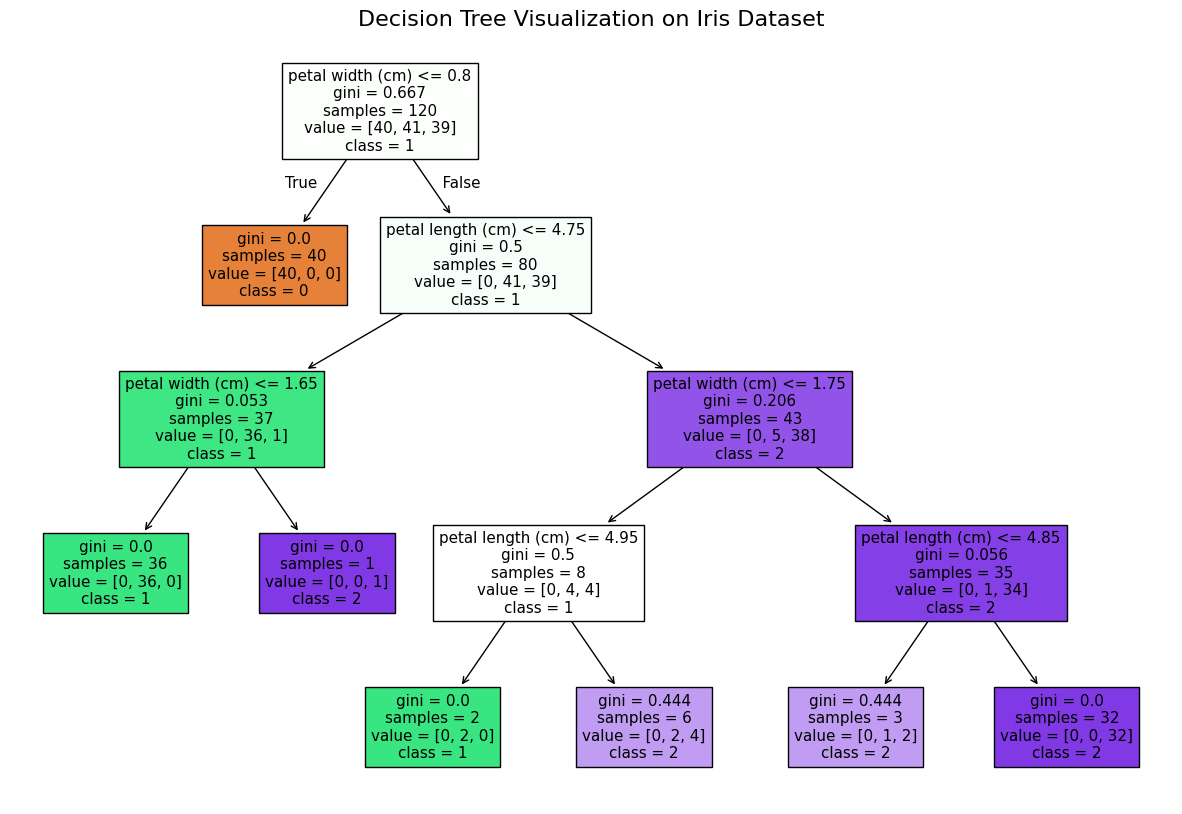

In [16]:
feature_names=['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
plt.figure(figsize=(15, 10))
plot_tree(grid_search.best_estimator_, filled=True, feature_names=feature_names, class_names=df['target'].unique().astype(str))
plt.title("Decision Tree Visualization on Iris Dataset", fontsize=16)
plt.show()

# Feature Importance বের করো।


In [18]:
importance=model.feature_importances_
importance_df=pd.DataFrame({'Feature':x.columns,'Importance':importance}).sort_values(by='Importance',ascending=False)
importance_df

,Feature,Importance
2,petal length (cm),0.906143
3,petal width (cm),0.077186
1,sepal width (cm),0.016670
0,sepal length (cm),0.000000


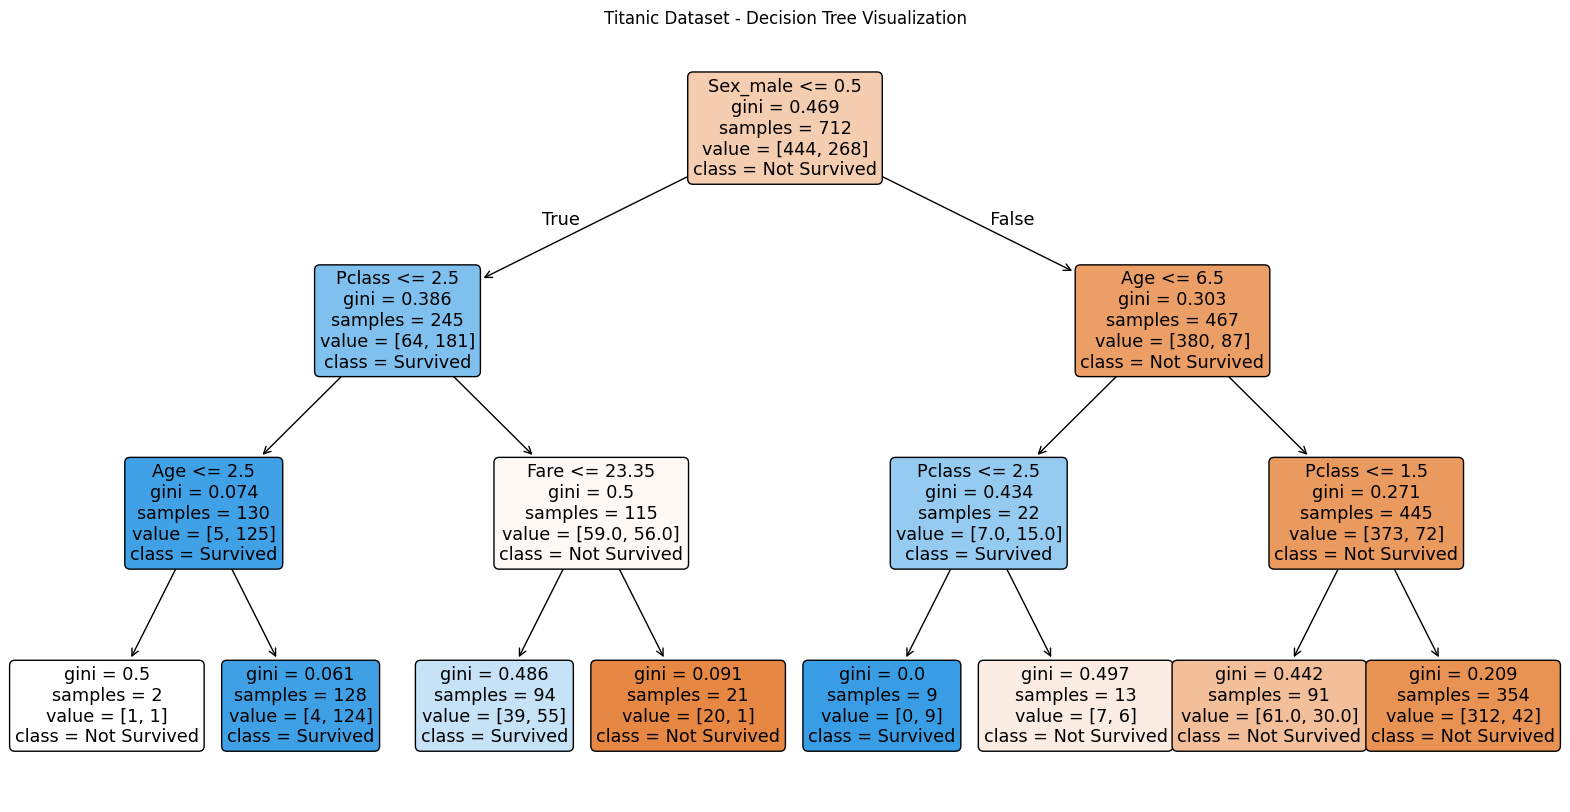

--- Accuracy ---
Accuracy Score: 79.89%

---  Confusion Matrix ---
[[92 13]
 [23 51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

--- 8. Feature Importance ---
   Feature  Importance
  Sex_male    0.623887
    Pclass    0.235428
       Age    0.077610
      Fare    0.063075
Embarked_Q    0.000000
Embarked_S    0.000000


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)


features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']
target = 'Survived'

X = df[features].copy()
y = df[target].copy()


X['Age'] = X['Age'].fillna(X['Age'].median())
X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])

X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


dt_model = DecisionTreeClassifier(max_depth=3, random_state=42) # সহজে বোঝার জন্য max_depth=3 দেওয়া হলো
dt_model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True, rounded=True)
plt.title("Titanic Dataset - Decision Tree Visualization")
plt.show()

y_pred = dt_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"--- Accuracy ---")
print(f"Accuracy Score: {accuracy * 100:.2f}%\n")

cm = confusion_matrix(y_test, y_pred)
print("---  Confusion Matrix ---")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

importances = dt_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("--- 8. Feature Importance ---")
print(feature_importance_df.to_string(index=False))